# 04 Sentiment Model Training

Goal: fine-tune `distilroberta-base` on `takala/financial_phrasebank` for 3-class sentiment classification (`positive`, `negative`, `neutral`).

This notebook covers:
- loading the dataset from Hugging Face
- train / validation split
- tokenization with `AutoTokenizer`
- model fine-tuning with the `Trainer` API
- evaluation using accuracy, precision, recall, and F1
- confusion matrix visualization
- saving the trained model
- example predictions


## 1. Environment Setup

Run the next cell if the required packages are not already installed in your environment.


In [1]:
# %pip install -q transformers datasets evaluate accelerate scikit-learn seaborn matplotlib pandas

## 2. Imports and Configuration


In [2]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import DatasetDict, load_dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

SEED = 42
MODEL_CHECKPOINT = "distilroberta-base"
DATASET_NAME = "takala/financial_phrasebank"
DATASET_CONFIG = "sentences_allagree"
TEXT_COLUMN = "sentence"
LABEL_COLUMN = "label"
OUTPUT_DIR = Path("./sentiment_distilroberta_financial_phrasebank")
MAX_LENGTH = 128
TEST_SIZE = 0.2
NUM_LABELS = 3

def set_seed(seed: int = 42) -> None:
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}")
print(f"Torch version: {torch.__version__}")


Using device: mps
Torch version: 2.10.0


## 3. Load and Inspect the Dataset

The dataset stores sentiment labels either as strings or `ClassLabel` integers depending on configuration, so we standardize them before training.


In [3]:
# Load one of the standard Financial PhraseBank configurations.
# Other common options are: sentences_75agree, sentences_66agree, sentences_50agree.
raw_dataset = load_dataset(
    DATASET_NAME,
    DATASET_CONFIG,
    trust_remote_code=True
)

raw_dataset


DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 2264
    })
})

In [4]:
print(raw_dataset)

default_split_name = list(raw_dataset.keys())[0]
base_dataset = raw_dataset[default_split_name]

print(f"Using split: {default_split_name}")
print(f"Number of examples: {len(base_dataset)}")
display(base_dataset.to_pandas().head())


DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 2264
    })
})
Using split: train
Number of examples: 2264


,sentence,label
0,"According to Gran , the company has no plans t...",1
1,"For the last quarter of 2010 , Componenta 's n...",2
2,"In the third quarter of 2010 , net sales incre...",2
3,Operating profit rose to EUR 13.1 mn from EUR ...,2
4,"Operating profit totalled EUR 21.1 mn , up fro...",2


In [5]:
label_list = ["negative", "neutral", "positive"]
label2id = {label: idx for idx, label in enumerate(label_list)}
id2label = {idx: label for label, idx in label2id.items()}

dataset_label_feature = base_dataset.features[LABEL_COLUMN]

def add_label_id(example):
    raw_label = example[LABEL_COLUMN]
    if isinstance(raw_label, str):
        label_text = raw_label
    else:
        label_text = dataset_label_feature.int2str(raw_label)
    example["label_text"] = label_text
    example["label_id"] = label2id[label_text]
    return example

base_dataset = base_dataset.map(add_label_id)
label_counts = pd.Series(base_dataset["label_text"]).value_counts().reindex(label_list, fill_value=0)
print("Label distribution:")
display(label_counts.to_frame(name="count"))


Label distribution:


,count
negative,303
neutral,1391
positive,570


## 4. Train / Validation Split

We create a stratified split so each sentiment class is represented proportionally in both sets.


In [6]:
indices = np.arange(len(base_dataset))
train_indices, val_indices = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=base_dataset["label_id"],
)

dataset = DatasetDict({
    "train": base_dataset.select(train_indices),
    "validation": base_dataset.select(val_indices),
})

print(dataset)
print("Train size:", len(dataset["train"]))
print("Validation size:", len(dataset["validation"]))


DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'label_text', 'label_id'],
        num_rows: 1811
    })
    validation: Dataset({
        features: ['sentence', 'label', 'label_text', 'label_id'],
        num_rows: 453
    })
})
Train size: 1811
Validation size: 453


## 5. Tokenization

We use `AutoTokenizer` from the same checkpoint as the model so tokenization matches pretraining.


In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def tokenize_batch(batch):
    """Tokenize a batch of sentences with truncation for sequence classification."""
    return tokenizer(
        batch[TEXT_COLUMN],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized_dataset = dataset.map(tokenize_batch, batched=True)
tokenized_dataset = tokenized_dataset.rename_column("label_id", "labels")
tokenized_dataset = tokenized_dataset.remove_columns([LABEL_COLUMN, "label_text"])
tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
tokenized_dataset


Map:   0%|          | 0/453 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 1811
    })
    validation: Dataset({
        features: ['sentence', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 453
    })
})

## 6. Model, Metrics, and Trainer Setup

`distilroberta-base` is a strong choice here because it is lighter than RoBERTa-base but usually stronger than vanilla BERT on many text classification tasks.


In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
)

def compute_metrics(eval_pred):
    """Compute classification metrics from model logits."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0,
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    seed=SEED,
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/k4/tvw2_4hs615cgbdrbjzqhybw0000gn/T/ipykernel_83974/2078507846.py:46: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


## 7. Fine-Tune the Model


In [9]:
train_result = trainer.train()
train_result


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.531500,0.114037,0.964680,0.966842,0.964680,0.964555
2,0.123200,0.123657,0.964680,0.966912,0.964680,0.965086
3,0.047600,0.100383,0.980132,0.980798,0.980132,0.980237
4,0.029600,0.100410,0.980132,0.980484,0.980132,0.980209


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=456, training_loss=0.18295517668389438, metrics={'train_runtime': 102.2379, 'train_samples_per_second': 70.854, 'train_steps_per_second': 4.46, 'total_flos': 109793628728712.0, 'train_loss': 0.18295517668389438, 'epoch': 4.0})

## 8. Evaluate on the Validation Set


In [10]:
eval_metrics = trainer.evaluate()
eval_metrics


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.10038266330957413,
 'eval_accuracy': 0.9801324503311258,
 'eval_precision': 0.9807980202092038,
 'eval_recall': 0.9801324503311258,
 'eval_f1': 0.980237288385863,
 'eval_runtime': 1.3114,
 'eval_samples_per_second': 345.428,
 'eval_steps_per_second': 22.113,
 'epoch': 4.0}

In [11]:
pred_output = trainer.predict(tokenized_dataset["validation"])
val_logits = pred_output.predictions
val_labels = pred_output.label_ids
val_preds = np.argmax(val_logits, axis=-1)

report = classification_report(
    val_labels,
    val_preds,
    target_names=label_list,
    zero_division=0,
)
print(report)


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    negative       0.98      0.95      0.97        61
     neutral       1.00      0.98      0.99       278
    positive       0.94      0.99      0.97       114

    accuracy                           0.98       453
   macro avg       0.97      0.97      0.97       453
weighted avg       0.98      0.98      0.98       453



## 9. Confusion Matrix


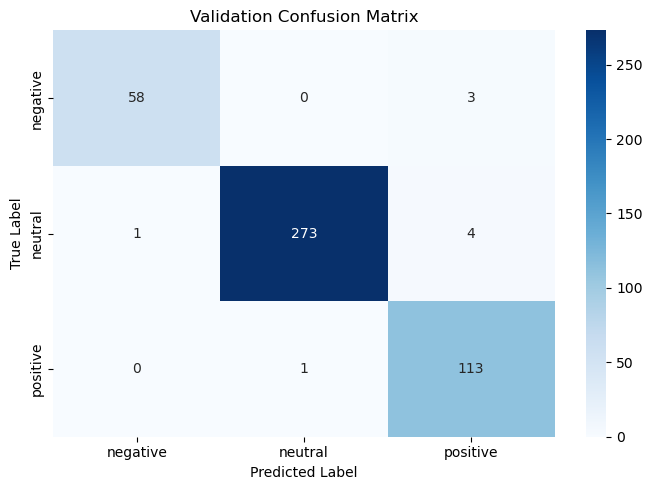

In [12]:
cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_list,
    yticklabels=label_list,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()


## 10. Save the Trained Model


In [14]:
trainer.save_model(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))

print(f"Saved model to: {OUTPUT_DIR.resolve()}")


Saved model to: /Users/jiayingzhong/Desktop/NLP/Final_project/sentiment_distilroberta_financial_phrasebank


## 11. Example Predictions

These examples show how the model can be applied to finance and AI-related headlines after fine-tuning.


In [15]:
classifier = pipeline(
    task="text-classification",
    model=str(OUTPUT_DIR),
    tokenizer=str(OUTPUT_DIR),
    device=0 if torch.cuda.is_available() else -1,
)

example_texts = [
    "Nvidia shares rise as companies increase spending on AI infrastructure.",
    "Startup cuts hundreds of jobs after automating support operations with AI tools.",
    "Executives remain cautious about the long-term return on enterprise AI investments.",
    "Bank expands use of generative AI to improve analyst productivity and reduce reporting time.",
]

predictions = classifier(example_texts)

prediction_df = pd.DataFrame({
    "text": example_texts,
    "predicted_label": [pred["label"] for pred in predictions],
    "confidence": [round(float(pred["score"]), 4) for pred in predictions],
})

prediction_df


Device set to use cpu


,text,predicted_label,confidence
0,Nvidia shares rise as companies increase spend...,positive,0.9976
1,Startup cuts hundreds of jobs after automating...,negative,0.9932
2,Executives remain cautious about the long-term...,negative,0.9891
3,Bank expands use of generative AI to improve a...,positive,0.9973


## 12. Notes for the Larger Project

After this notebook, the saved sentiment model can be loaded and applied to AI-related news articles. A practical downstream pipeline would be:
1. run topic and entity extraction on the article
2. score the headline or summary with this sentiment model
3. combine sentiment with extracted companies, industries, and impact mechanisms
4. aggregate results across articles to identify who is most positively or negatively affected by AI
